In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('source/FReDA4.csv')
df["Group4"] = None

In [3]:
# Satisfied
df.loc[df['Group3'] == 'Couple Satisfaction', 'Group4'] = 'Couple Satisfaction'

# Deprived groups
df.loc[df['Group1'] == 'SubGroup-DeprivedBoth', 'Group4'] = 'Deprived_Both'
df.loc[df['Group1'] == 'SubGroup-DeprivedMe', 'Group4'] = 'Deprived_Me'
df.loc[df['Group1'] == 'SubGroup-DeprivedPartner', 'Group4'] = 'Deprived_Partner'
#
# Oversaturated groups
df.loc[df['Group1'] == 'SubGroup-OversaturatedBoth', 'Group4'] = 'Oversaturated_Both'
df.loc[df['Group1'] == 'SubGroup-OversaturatedMe', 'Group4'] = 'Oversaturated_Me'
df.loc[df['Group1'] == 'SubGroup-OversaturatedPartner', 'Group4'] = 'Oversaturated_Partner'

df.loc[df['Group3'] == 'Couple Mixed', 'Group4'] = 'Mixed couple'

In [4]:
df = df.rename(columns={
    'Relationship Satisfaction': 'Relationship_Satisfaction',
    'Relationship Length (years)': 'Relationship_Length_years',
})

In [5]:
def collapse_kde_into_bins(kde_df, bins=[0, 1, 2, 3, 4, 5, 6]):
    df = kde_df.copy()
    N = df["N_total"].iloc[0]

    dx = df["x"].diff().median()

    df["bin"] = pd.cut(df["x"], bins=bins, labels=range(len(bins) - 1), right=False)

    out = (
        df.groupby("bin")
        .apply(lambda g: pd.Series({
            "density_sum": (g["density"] * dx).sum(),
        }))
        .reset_index()
    )
    return out

In [6]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask1.get(cid, False) else 0
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask1.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask2.get(cid, False) else 0
)

df['Match_Desire_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask2.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask2.get(cid, False) else 0
)

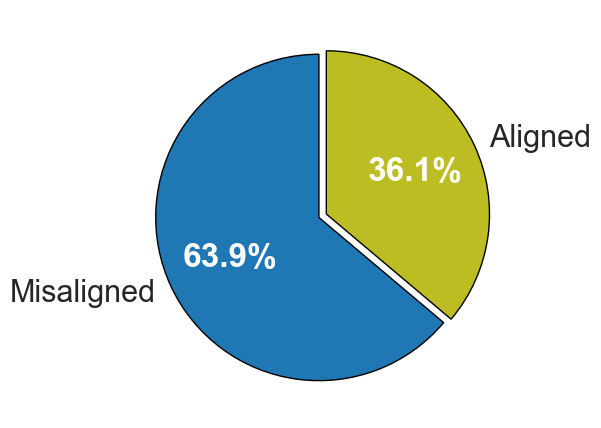

In [30]:
sns.set_context("poster")

custom_colors = ["#1f77b4", "#bcbd22"]

wedges, texts, autotexts = plt.pie(
    x=df["Match_Frequency_n"].value_counts(),
    labels=["Misaligned", "Aligned"],
    colors=custom_colors,
    autopct='%.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    explode=[0.05, 0],
    # textprops={'color': 'white', 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('output/img/Alignment3.png', dpi=600, transparent=True, bbox_inches='tight')

In [460]:
(df[df['Group3'] == "Couple Satisfaction"]['Match_Frequency'].value_counts(normalize=True) * 100).round(1)

# df2 = df[df["Match_Frequency"] == "Aligned"].copy()
# df3 = df[df["Match_Desire"] == "Aligned"].copy()

Match_Frequency
Misaligned    61.7
Aligned       38.3
Name: proportion, dtype: float64

In [437]:
# sns.kdeplot(
#    data=df, x="Relationship Length (years)", hue="Match_Frequency",
#    fill=True, common_norm=False, palette="icefire",
#    alpha=.5, linewidth=0,
# )

In [438]:
# sns.kdeplot(
#    data=df, x="Relationship Satisfaction", hue="Match_Frequency",
#    fill=True, common_norm=False, palette="icefire",
#    alpha=.5, linewidth=0,
# )

In [439]:
# sns.kdeplot(
#    data=df, x="Frequency_F", hue="Match_Frequency",
#    fill=True, common_norm=False, palette="icefire",
#    alpha=.5, linewidth=0,
# )

In [440]:
new_palette = [
    "#C4A000",
    "#B76A8D",
    "#355C9C",
    "#009688",
]

groups_order = [
    "Couple Satisfaction",
    "Couple Deprivation",
    "Couple Oversaturation",
    "Couple Mixed",
]


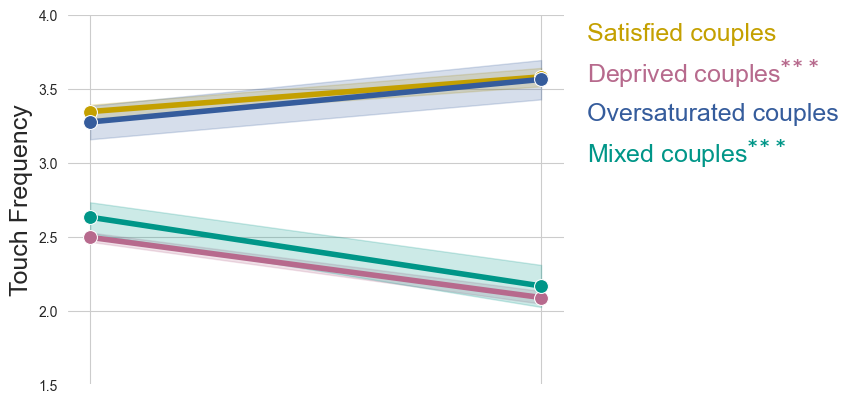

In [458]:
ax = sns.lineplot(
    data=df,
    y="Frequency_F",
    x="Match_Frequency",
    hue="Group3",
    hue_order=groups_order,
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    # markeredgecolor='none',
    dashes=False,
    linewidth=4,
    estimator="mean",
)

plt.ylabel("Touch Frequency", fontsize=18)
# plt.xlabel("Couple Alignment Status", fontsize=18)

plt.xlabel("")
ax.tick_params(axis='x', labelbottom=False)

handles, labels = ax.get_legend_handles_labels()
# new_labels = ["Satisfied couples", "Deprived couples ***", "Oversaturated couples", "Mixed couples ***"]
# plt.legend(handles=handles, labels=new_labels, loc='upper right', bbox_to_anchor=(1.8, 1.04), frameon=False, fontsize=18)

new_labels = [
    "Satisfied couples",
    "Deprived couples$^{\mathbf{***}}$",
    "Oversaturated couples",
    "Mixed couples$^{\mathbf{***}}$",
]

leg = plt.legend(
    handles=handles,
    labels=new_labels,
    loc='upper right',
    bbox_to_anchor=(1.6, 1.04),
    frameon=False,
    fontsize=18,
    handlelength=0,
    handletextpad=0,
    markerscale=0
)

for item in leg.legend_handles:
    item.set_visible(False)

for text, handle in zip(leg.get_texts(), handles):
    text.set_color(handle.get_color())

plt.ylim(1.5, 4)

sns.despine(top=True, right=True, left=True, bottom=True)
ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
plt.savefig('output/img/alignment/frequency.png', dpi=600, transparent=False, bbox_inches='tight')

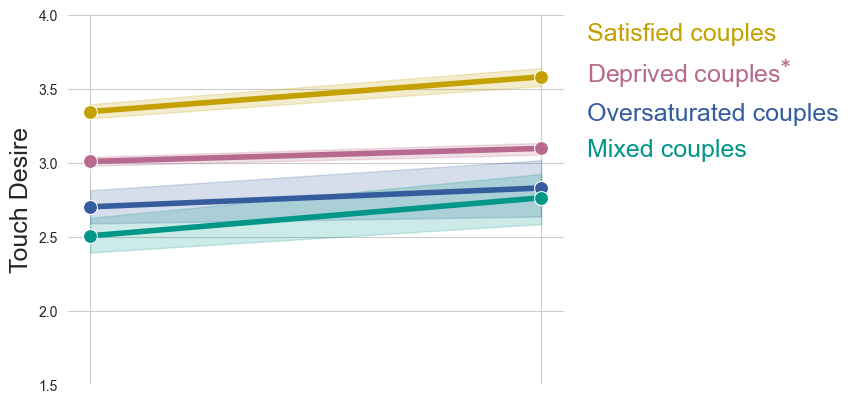

In [457]:
ax = sns.lineplot(
    data=df,
    y="Desire_F",
    x="Match_Desire",
    hue="Group3",
    hue_order=groups_order,
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    # markeredgecolor='none',
    dashes=False,
    linewidth=4,
    estimator="mean",
)

plt.ylabel("Touch Desire", fontsize=18)
# plt.xlabel("Couple Alignment Status", fontsize=18)

plt.xlabel("")
ax.tick_params(axis='x', labelbottom=False)

handles, labels = ax.get_legend_handles_labels()
# new_labels = ["Satisfied couples", "Deprived couples *", "Oversaturated couples", "Mixed couples", ]
# plt.legend(handles=handles, labels=new_labels, loc='upper right', bbox_to_anchor=(1.8, 1.04), frameon=False,
#            fontsize=18)

new_labels = [
    "Satisfied couples",
    "Deprived couples$^{\mathbf{*}}$",
    "Oversaturated couples",
    "Mixed couples",
]

leg = plt.legend(
    handles=handles,
    labels=new_labels,
    loc='upper right',
    bbox_to_anchor=(1.6, 1.04),
    frameon=False,
    fontsize=18,
    handlelength=0,
    handletextpad=0,
    markerscale=0
)

for item in leg.legend_handles:
    item.set_visible(False)

for text, handle in zip(leg.get_texts(), handles):
    text.set_color(handle.get_color())

plt.ylim(1.5, 4)

sns.despine(top=True, right=True, left=True, bottom=True)
ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
plt.savefig('output/img/alignment/desire.png', dpi=600, transparent=False, bbox_inches='tight')

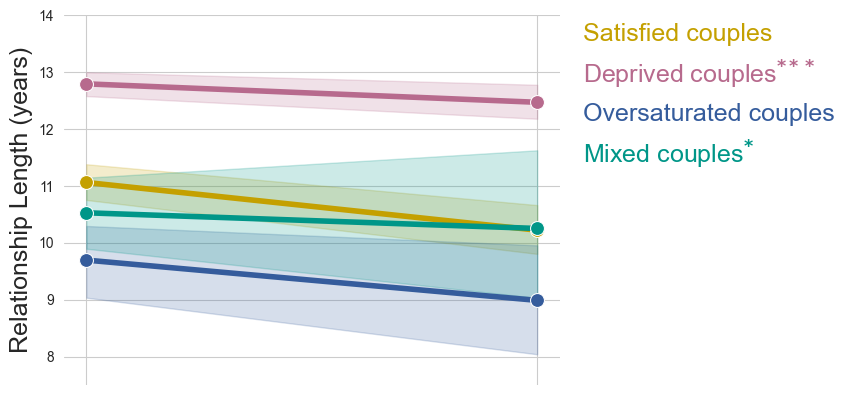

In [456]:
ax = sns.lineplot(
    data=df,
    y="Relationship_Length_years",
    x="Match_Desire",
    hue="Group3",
    hue_order=groups_order,
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Relationship Length (years)", fontsize=18)
# plt.xlabel("Couple Alignment Status", fontsize=18)

plt.xlabel("")
ax.tick_params(axis='x', labelbottom=False)

handles, labels = ax.get_legend_handles_labels()
# new_labels = ["Satisfied couples", "Deprived couples ***", "Mixed couples *", "Oversaturated couples"]
# plt.legend(handles=handles, labels=new_labels, loc='upper right', bbox_to_anchor=(1.8, 1.04), frameon=False, fontsize=18)

new_labels = [
    "Satisfied couples",
    "Deprived couples$^{\mathbf{***}}$",
    "Oversaturated couples",
    "Mixed couples$^{\mathbf{*}}$",
]

leg = plt.legend(
    handles=handles,
    labels=new_labels,
    loc='upper right',
    bbox_to_anchor=(1.6, 1.04),
    frameon=False,
    fontsize=18,
    handlelength=0,
    handletextpad=0,
    markerscale=0
)

for item in leg.legend_handles:
    item.set_visible(False)

for text, handle in zip(leg.get_texts(), handles):
    text.set_color(handle.get_color())

plt.ylim(7.5, 14)

sns.despine(top=True, right=True, left=True, bottom=True)
ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
plt.savefig('output/img/alignment/rel_len.png', dpi=600, transparent=False, bbox_inches='tight')

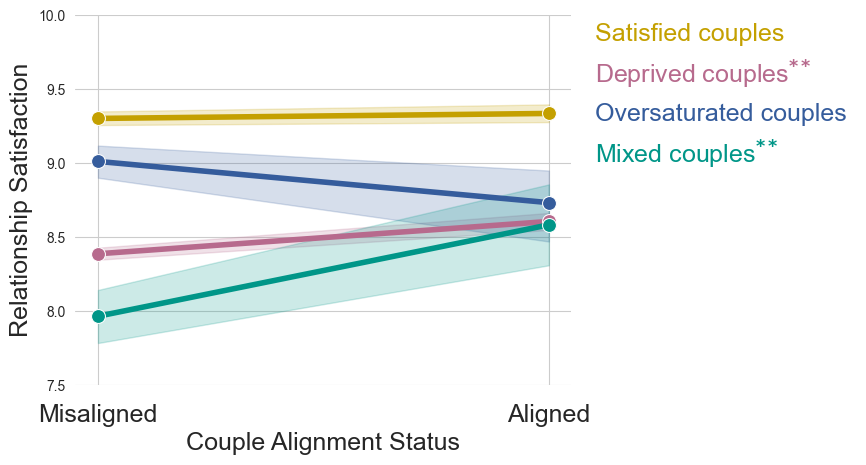

In [455]:
ax = sns.lineplot(
    data=df,
    y="Relationship_Satisfaction",
    x="Match_Desire",
    hue="Group3",
    hue_order=groups_order,
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Relationship Satisfaction", fontsize=18)
plt.xlabel("Couple Alignment Status", fontsize=18)
#
# plt.xlabel("")
# plt.xticks([])

# handles, labels = ax.get_legend_handles_labels()
# new_labels = ["Satisfied couples", "Deprived couples **", "Mixed couples **", "Oversaturated couples"]
# plt.legend(handles=handles, labels=new_labels, loc='upper right', bbox_to_anchor=(1.8, 1.04), frameon=False, fontsize=18)
# 1. Create the legend with zero-sized handles

new_labels = [
    "Satisfied couples",
    "Deprived couples$^{\mathbf{**}}$",
    "Oversaturated couples",
    "Mixed couples$^{\mathbf{**}}$",
]

leg = plt.legend(
    handles=handles,
    labels=new_labels,
    loc='upper right',
    bbox_to_anchor=(1.6, 1.04),
    frameon=False,
    fontsize=18,
    handlelength=0,
    handletextpad=0,
    markerscale=0
)

for item in leg.legend_handles:
    item.set_visible(False)

for text, handle in zip(leg.get_texts(), handles):
    text.set_color(handle.get_color())

plt.ylim(7.5, 10)

sns.despine(top=True, right=True, left=True, bottom=True)
ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
plt.savefig('output/img/alignment/rel_sat.png', dpi=600, transparent=False, bbox_inches='tight')

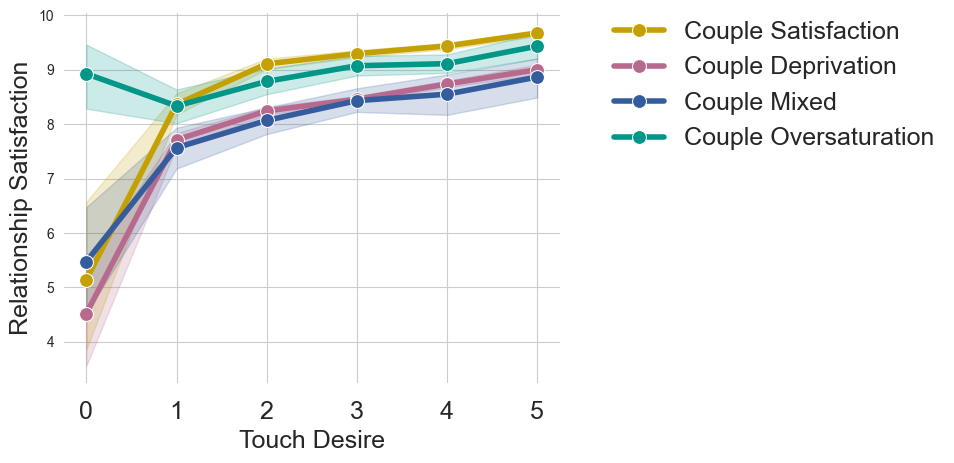

In [445]:
ax = sns.lineplot(
    data=df,
    y="Relationship_Satisfaction",
    x="Desire_F",
    hue="Group3",
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Relationship Satisfaction", fontsize=18)
plt.xlabel("Touch Desire", fontsize=18)

# plt.ylim(1.5, 4)

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.8, 1.04),
    fontsize=18,
    frameon=False,
)

sns.despine(top=True, right=True, left=True, bottom=True)
# t1 = plt.title("Touch Desire", fontsize=24, y=1.05, x=0.01, ha='left')

ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
# plt.savefig('output/img/alignment/desire.png', dpi=600, transparent=False, bbox_inches='tight')

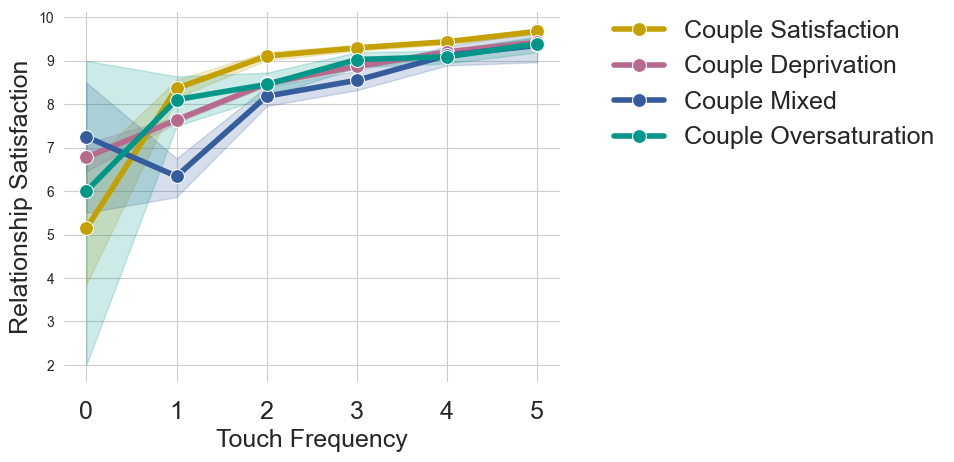

In [446]:
ax = sns.lineplot(
    data=df,
    y="Relationship_Satisfaction",
    x="Frequency_F",
    hue="Group3",
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Relationship Satisfaction", fontsize=18)
plt.xlabel("Touch Frequency", fontsize=18)

# plt.ylim(1.5, 4)

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.8, 1.04),
    fontsize=18,
    frameon=False,
)

sns.despine(top=True, right=True, left=True, bottom=True)
# t1 = plt.title("Touch Desire", fontsize=24, y=1.05, x=0.01, ha='left')

ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
# plt.savefig('output/img/alignment/desire.png', dpi=600, transparent=False, bbox_inches='tight')

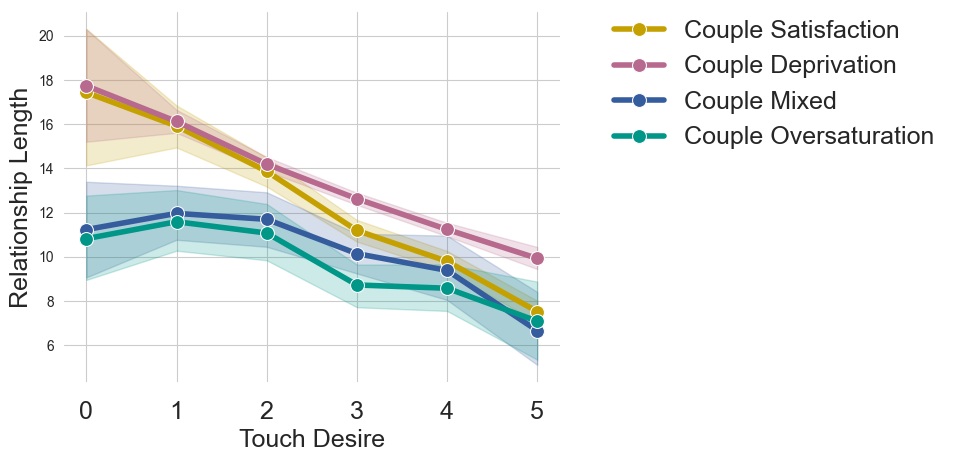

In [447]:
ax = sns.lineplot(
    data=df,
    y="Relationship_Length_years",
    x="Desire_F",
    hue="Group3",
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Relationship Length", fontsize=18)
plt.xlabel("Touch Desire", fontsize=18)

# plt.ylim(1.5, 4)

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.8, 1.04),
    fontsize=18,
    frameon=False,
)

sns.despine(top=True, right=True, left=True, bottom=True)
# t1 = plt.title("Touch Desire", fontsize=24, y=1.05, x=0.01, ha='left')

ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
# plt.savefig('output/img/alignment/desire.png', dpi=600, transparent=False, bbox_inches='tight')

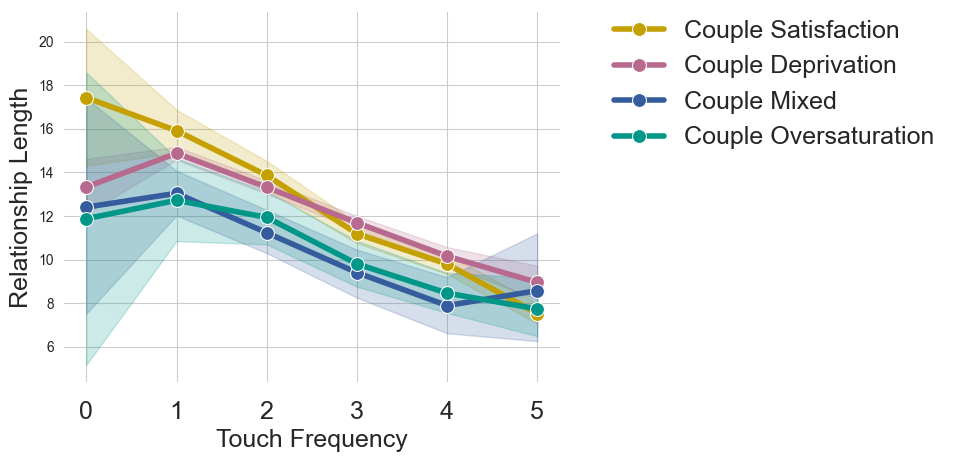

In [448]:
ax = sns.lineplot(
    data=df,
    y="Relationship_Length_years",
    x="Frequency_F",
    hue="Group3",
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Relationship Length", fontsize=18)
plt.xlabel("Touch Frequency", fontsize=18)

# plt.ylim(1.5, 4)

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.8, 1.04),
    fontsize=18,
    frameon=False,
)

sns.despine(top=True, right=True, left=True, bottom=True)
# t1 = plt.title("Touch Desire", fontsize=24, y=1.05, x=0.01, ha='left')

ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
# plt.savefig('output/img/alignment/desire.png', dpi=600, transparent=False, bbox_inches='tight')

In [449]:
# # new_palette = [
# #     "#C4A000",
# #     "#355C9C",
# #     "#B76A8D",
# #     "#009688",
# # ]
# # target_values = ['Deprived_Both', 'Deprived_Me', 'Deprived_Partner']
# target_values = ['Oversaturated_Both', 'Oversaturated_Me', 'Oversaturated_Partner']
# df_filtered = df[df['Group4'].isin(target_values)]
#
# ax = sns.lineplot(
#     data=df_filtered,
#     y="Frequency_F",
#     x="Match_Frequency",
#     hue="Group4",
#     style='Group4',
#     # palette=new_palette,
#     # markers=["o", "o", "o", "o"],
#     dashes=False,
# )
#
# plt.ylabel("Touch Frequency")
# plt.xlabel("Couple Alignment")
#
# plt.ylim(1.5, 4)
# # plt.xticks([0, 1], labels=["Align", "Disalign"])
#
# x_legend = plt.legend(
#     loc='upper right',
#     bbox_to_anchor=(1.5, 1.04),
#     fontsize=11
# )
#
# ax.tick_params(axis='x', which='major', pad=10)

In [450]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

analysis_cols = [
    "Match_Frequency_n",
    "Match_Desire_n",
    "Relationship_Length_years",
    "Frequency_F",
    "Desire_F",
    "Relationship_Satisfaction",
    "Role",
    "CoupleId",
    "Group3"
]

df_clean = df[analysis_cols].dropna()

# ---------------------------------------------------------
# 1. TEST FOR THE TOUCH FREQUENCY PLOT
# Here, we interact Frequency_F with Group3
# ---------------------------------------------------------
model_frequency = smf.logit(
    "Match_Frequency_n ~ Relationship_Length_years + Relationship_Satisfaction + Frequency_F * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_freq = model_frequency.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
print("=== TOUCH FREQUENCY PLOT RESULTS ===")
print(result_freq.summary())


# ---------------------------------------------------------
# 2. TEST FOR THE TOUCH DESIRE PLOT
# Here, we interact Desire_F with Group3 (predicting Match_Desire_n)
# ---------------------------------------------------------
model_desire = smf.logit(
    "Match_Desire_n ~ Relationship_Length_years + Relationship_Satisfaction + Desire_F * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_desire = model_desire.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
print("\n=== TOUCH DESIRE PLOT RESULTS ===")
print(result_desire.summary())


# ---------------------------------------------------------
# 3. TEST FOR THE RELATIONSHIP LENGTH PLOT
# Here, we interact Relationship_Length_years with Group3
# ---------------------------------------------------------
model_len = smf.logit(
    "Match_Frequency_n ~ Frequency_F + Relationship_Satisfaction + Relationship_Length_years * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_len = model_len.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
print("\n=== RELATIONSHIP LENGTH PLOT RESULTS ===")
print(result_len.summary())


# ---------------------------------------------------------
# 4. TEST FOR THE RELATIONSHIP SATISFACTION PLOT
# Here, we interact Relationship_Satisfaction with Group3
# ---------------------------------------------------------
model_sat = smf.logit(
    "Match_Frequency_n ~ Relationship_Length_years + Frequency_F + Relationship_Satisfaction * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_sat = model_sat.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
print("\n=== RELATIONSHIP SATISFACTION PLOT RESULTS ===")
print(result_sat.summary())

Optimization terminated successfully.
         Current function value: 0.643112
         Iterations 5
=== TOUCH FREQUENCY PLOT RESULTS ===
                           Logit Regression Results                           
Dep. Variable:      Match_Frequency_n   No. Observations:                13302
Model:                          Logit   Df Residuals:                    13292
Method:                           MLE   Df Model:                            9
Date:                Sat, 23 May 2026   Pseudo R-squ.:                 0.01747
Time:                        21:00:58   Log-Likelihood:                -8554.7
converged:                       True   LL-Null:                       -8706.8
Covariance Type:              cluster   LLR p-value:                 3.350e-60
                                                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------